# Warm-started multi-task liver and tumor localization

## tl;dr

Validation-only 3D cleanup could not reduce false positives without losing patient Dice. This experiment changes the learned task instead: one shared MobileNetV2-U-Net predicts both the liver and tumor. Tumor output is constrained by the model's **predicted liver**, never by the ground-truth organ mask at evaluation.

The tumor branch is warm-started from the strongest intensity-normalized checkpoint. The test split remains locked. The primary gate is patient-level tumor performance plus false-positive and small-lesion guardrails.

## Context & Methods

### Key assumptions

- The verified manifest and `Practice/` artifacts remain authoritative.
- Organ masks are training supervision only; ground-truth organ masks are not used for validation preprocessing or prediction gating.
- The intensity-normalized checkpoint is the comparison baseline and warm start.
- Model selection uses validation patients only.
- Passing this notebook permits one frozen test evaluation; failing it does not.

### Required outcome

Retain mean patient Dice and volumes 104/116 while reducing empty-slice false positives through learned anatomical localization.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib, json, platform, random, subprocess, sys, time, warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
SOURCE_DIR = PROJECT_ROOT / "Practice" / "intensity_robustness_outputs"
POSTPROCESS_DIR = PROJECT_ROOT / "Practice" / "validation_3d_postprocessing_outputs"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "multitask_liver_tumor_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_CHECKPOINT = SOURCE_DIR / "patient_aware_best.pth"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
RUN_TRAINING = True
RESUME_IF_AVAILABLE = True
EPOCHS = 15
DECISION_EPOCH = 10
BATCH_SIZE = 8
VALIDATION_BATCH_SIZE = 16
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
MIN_LEARNING_RATE = 2e-6
WEIGHT_DECAY = 1e-4
POSITIVE_SAMPLE_WEIGHT = 3.0
ORGAN_Z_CLIP = 3.0
TUMOR_THRESHOLD = 0.50
LIVER_THRESHOLD = 0.50
LIVER_DILATION_KERNEL = 31
TUMOR_LOSS_WEIGHT = 0.72
LIVER_LOSS_WEIGHT = 0.23
CONTAINMENT_LOSS_WEIGHT = 0.05
USE_MIXED_PRECISION = True
MAX_START_GPU_TEMP_C = 84
EMERGENCY_STOP_TEMP_C = 90
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)

TARGETS = {
    "mean_patient_dice": 0.406915,
    "volume_104_dice": 0.50,
    "volume_116_dice": 0.05,
    "q1_detected_pct": 45.0,
    "positive_predicted_empty_pct": 20.0,
    "empty_slice_false_positive_pct": 15.0,
    "mean_liver_dice": 0.90,
}

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0 | CUDA: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\multitask_liver_tumor_outputs


### 1. Experiment process

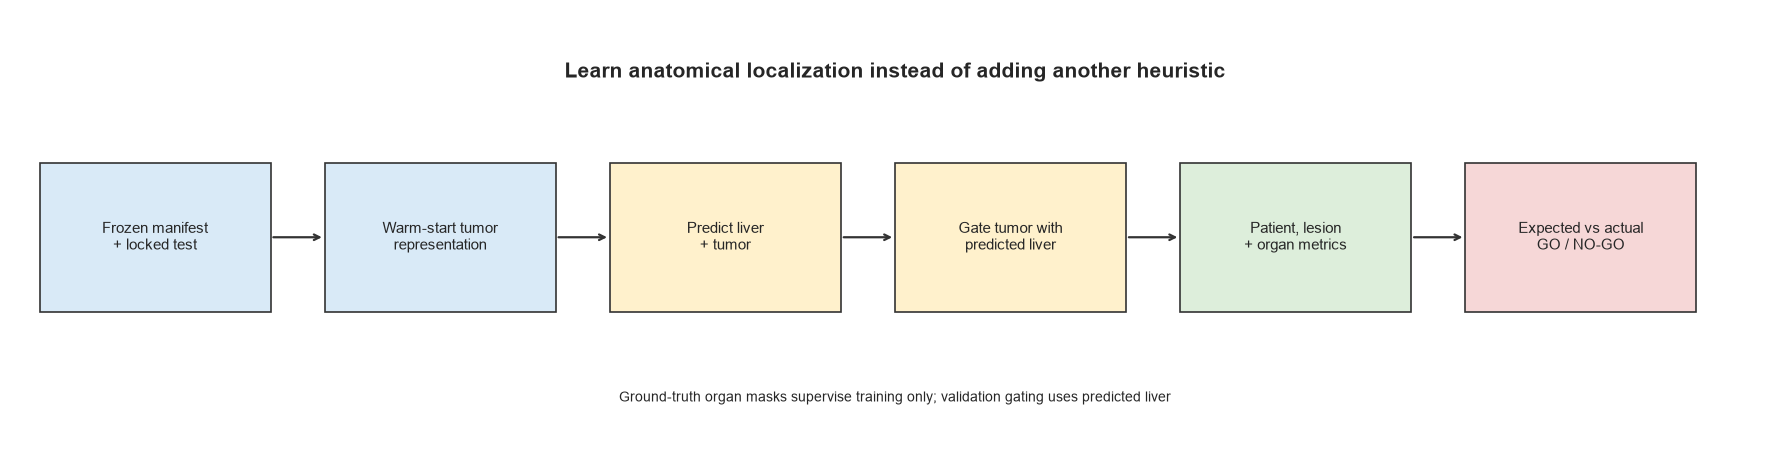

In [2]:
fig, axis = plt.subplots(figsize=(18, 4.8))
axis.set_xlim(0, 18); axis.set_ylim(0, 5); axis.axis("off")
steps = [
    (0.3, "Frozen manifest\n+ locked test", "#D9EAF7"),
    (3.2, "Warm-start tumor\nrepresentation", "#D9EAF7"),
    (6.1, "Predict liver\n+ tumor", "#FFF1CC"),
    (9.0, "Gate tumor with\npredicted liver", "#FFF1CC"),
    (11.9, "Patient, lesion\n+ organ metrics", "#DDEEDB"),
    (14.8, "Expected vs actual\nGO / NO-GO", "#F6D7D7"),
]
for x, label, color in steps:
    axis.add_patch(plt.Rectangle((x, 1.65), 2.35, 1.65, facecolor=color,
                                 edgecolor="#333333", linewidth=1.2))
    axis.text(x+1.175, 2.475, label, ha="center", va="center", fontsize=11)
for left, right in zip(steps[:-1], steps[1:]):
    axis.annotate("", xy=(right[0], 2.475), xytext=(left[0]+2.35, 2.475),
                  arrowprops={"arrowstyle": "->", "linewidth": 1.6, "color": "#333333"})
axis.text(9, 4.25, "Learn anatomical localization instead of adding another heuristic",
          ha="center", fontsize=15, weight="bold")
axis.text(9, 0.65, "Ground-truth organ masks supervise training only; validation gating uses predicted liver",
          ha="center", fontsize=10)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "multitask_process_map.png", dpi=170, bbox_inches="tight")
plt.show()

## Data

### 2. Verify provenance and lock test access

In [3]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset

def sha256_file(path, chunk_size=1024*1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

manifest_hash = sha256_file(MANIFEST_PATH)
source_checkpoint_hash = sha256_file(SOURCE_CHECKPOINT)
assert manifest_hash == EXPECTED_MANIFEST_SHA256
manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 58_638 and manifest["sample_id"].is_unique
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as exc:
    print(f"PASS: test split locked: {exc}")
else:
    raise AssertionError("Test split opened without explicit authorization.")

sets = {split: set(manifest.loc[manifest["split"].eq(split), "volume_id"])
        for split in ("train", "val", "test")}
assert sets["train"].isdisjoint(sets["val"])
assert sets["train"].isdisjoint(sets["test"])
assert sets["val"].isdisjoint(sets["test"])
print(f"PASS: manifest {manifest_hash[:12]}...; warm start {source_checkpoint_hash[:12]}...")

PASS: test split locked: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.
PASS: manifest 575a6fc391d6...; warm start 5f18223c0f61...


### 3. Build paired image, liver, and tumor targets

In [4]:
def image_robust_normalize(image):
    image = np.asarray(image, dtype=np.float32)
    reference = image[image > 0]
    if reference.size < 32:
        reference = image.reshape(-1)
    center = float(np.median(reference))
    q25, q75 = np.percentile(reference, [25, 75])
    robust_sigma = float((q75-q25)/1.349)
    if not np.isfinite(robust_sigma) or robust_sigma < 1e-3:
        robust_sigma = max(float(np.std(reference)), 1e-3)
    normalized = np.clip((image-center)/robust_sigma, -ORGAN_Z_CLIP, ORGAN_Z_CLIP)
    return ((normalized+ORGAN_Z_CLIP)/(2*ORGAN_Z_CLIP)).astype(np.float32)


class MultiTaskAugment:
    def __call__(self, image, liver, tumor):
        if random.random() < 0.30:
            image, liver, tumor = (
                np.fliplr(image).copy(), np.fliplr(liver).copy(), np.fliplr(tumor).copy()
            )
        if random.random() < 0.60:
            h, w = image.shape
            matrix = cv2.getRotationMatrix2D(
                (w/2, h/2), random.uniform(-10, 10), random.uniform(0.95, 1.05)
            )
            matrix[:, 2] += [
                random.uniform(-0.05, 0.05)*w,
                random.uniform(-0.05, 0.05)*h,
            ]
            image = cv2.warpAffine(image, matrix, (w, h), flags=cv2.INTER_LINEAR)
            liver = cv2.warpAffine(liver, matrix, (w, h), flags=cv2.INTER_NEAREST)
            tumor = cv2.warpAffine(tumor, matrix, (w, h), flags=cv2.INTER_NEAREST)
        if random.random() < 0.50:
            image = np.power(np.clip(image, 0, 1), random.uniform(0.85, 1.15))
        if random.random() < 0.35:
            image += np.random.normal(0, random.uniform(0, 0.025), image.shape)
        return (
            np.ascontiguousarray(np.clip(image, 0, 1), dtype=np.float32),
            np.ascontiguousarray(liver > 0.5, dtype=np.float32),
            np.ascontiguousarray(tumor > 0.5, dtype=np.float32),
        )


class MultiTaskDataset(Dataset):
    def __init__(self, base, transform=None):
        self.base, self.rows, self.transform = base, base.rows, transform
    def __len__(self): return len(self.base)
    @property
    def tumor_positive_flags(self): return self.base.tumor_positive_flags
    def __getitem__(self, index):
        sample = self.base[index]
        image = sample["image"][0].numpy()
        tumor = sample["mask"][0].numpy()
        with Image.open(self.rows[index]["organ_mask_path"]) as handle:
            liver = (np.asarray(handle.convert("L"), dtype=np.uint8) > 0).astype(np.float32)
        image = image_robust_normalize(image)
        if self.transform:
            image, liver, tumor = self.transform(image, liver, tumor)
        sample["image"] = torch.from_numpy(image[None]).float()
        sample["mask"] = torch.from_numpy(tumor[None]).float()
        sample["organ_mask"] = torch.from_numpy(liver[None]).float()
        return sample

train_base = VerifiedManifestDataset(MANIFEST_PATH, split="train", root_dir=DATASET_ROOT,
                                     target="tumor", transform=None, validate_paths=True)
val_base = VerifiedManifestDataset(MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
                                   target="tumor", transform=None, validate_paths=True)
train_dataset = MultiTaskDataset(train_base, MultiTaskAugment())
val_dataset = MultiTaskDataset(val_base)
flags = np.asarray(train_dataset.tumor_positive_flags, dtype=bool)
weights = np.where(flags, POSITIVE_SAMPLE_WEIGHT, 1.0)
sampler_generator = torch.Generator().manual_seed(SEED)
sampler = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double),
                                len(train_dataset), replacement=True,
                                generator=sampler_generator)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
print(f"Train={len(train_dataset):,} | validation={len(val_dataset):,}")

Train=40,667 | validation=10,685


### 4. Visual target and containment audit

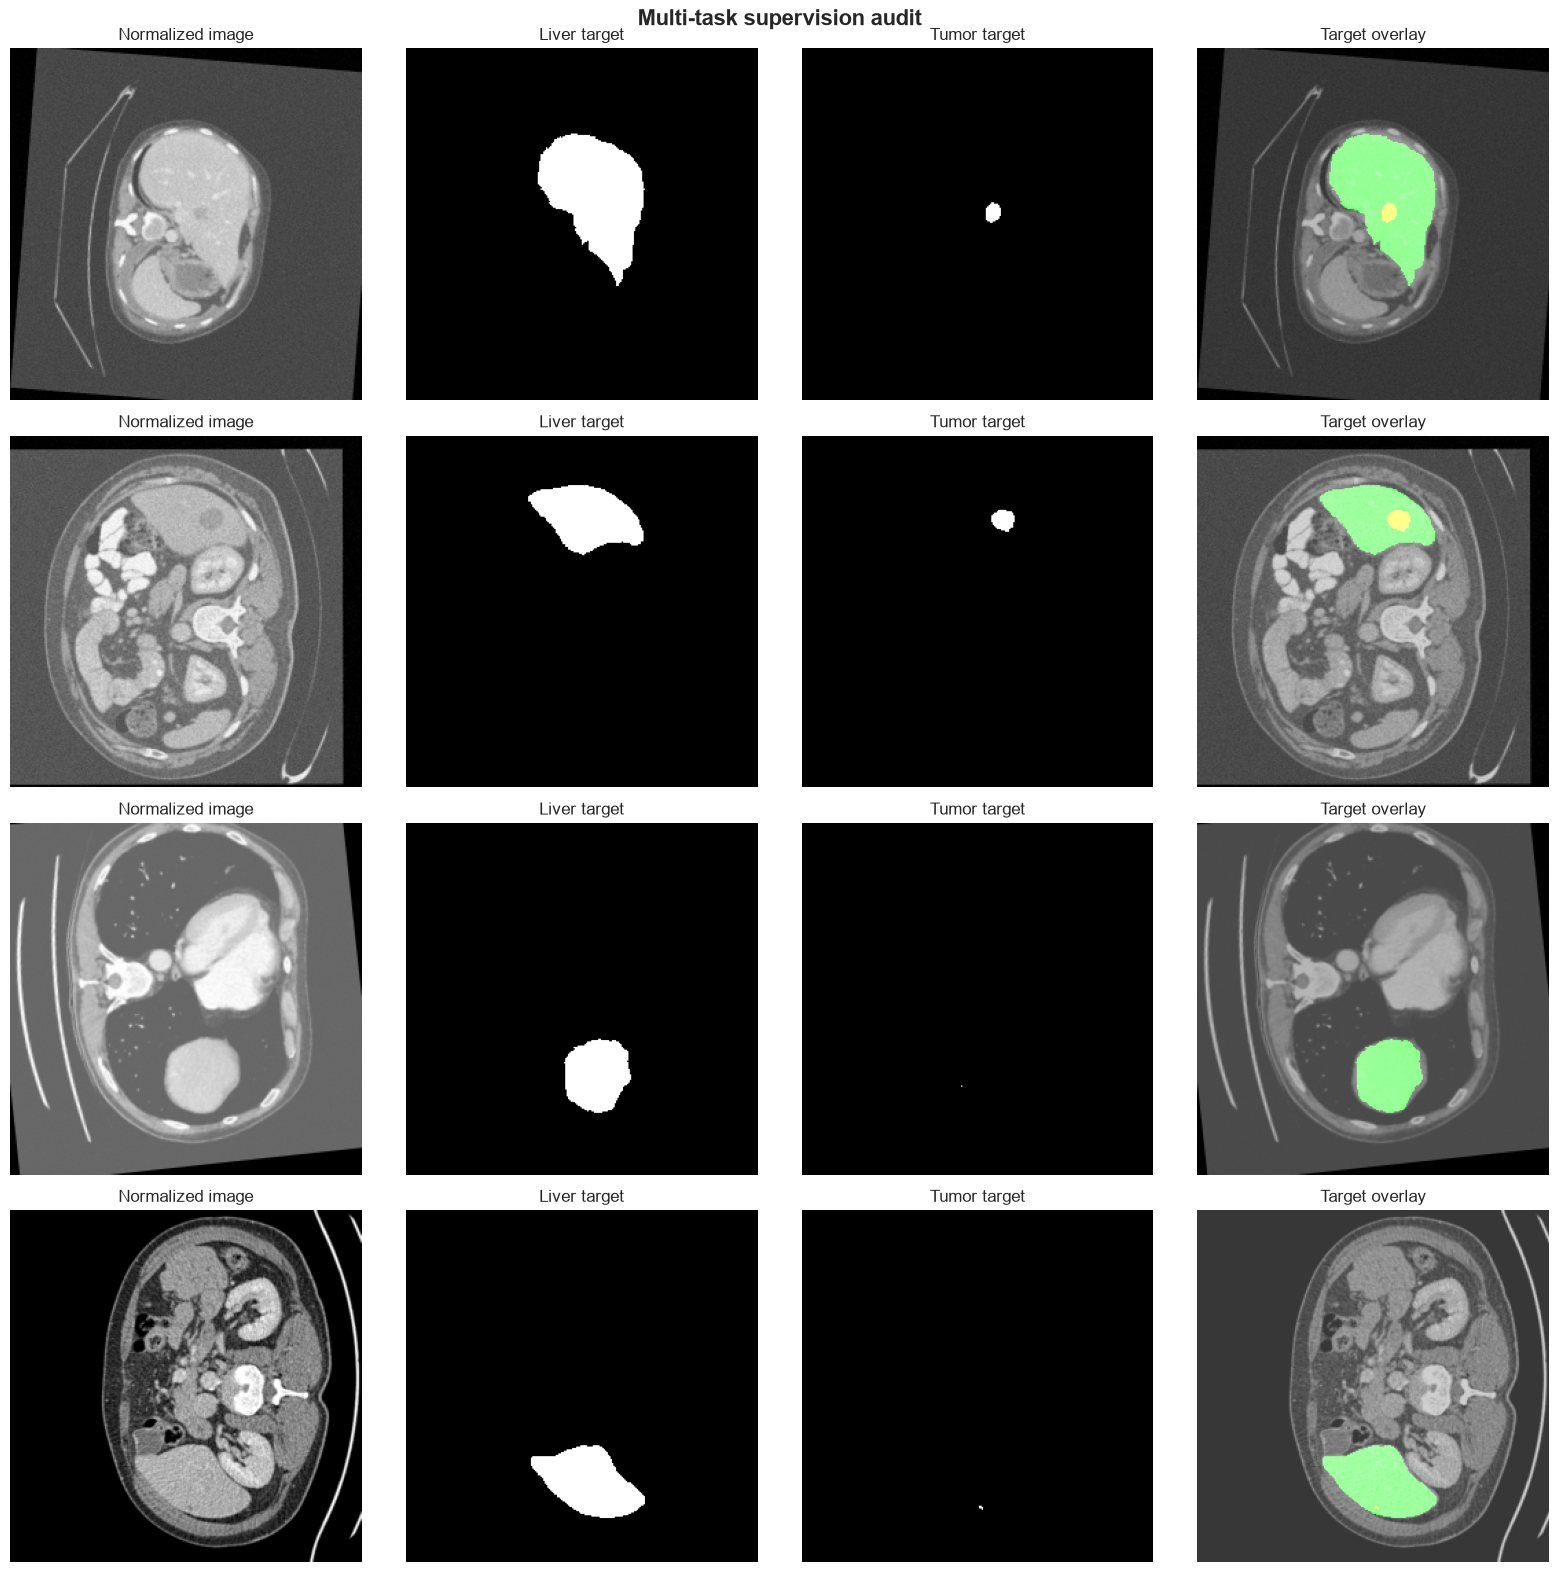

In [5]:
positive_indices = np.flatnonzero(flags)
preview_indices = np.random.default_rng(SEED).choice(positive_indices, 4, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for row_axes, index in zip(axes, preview_indices):
    item = train_dataset[int(index)]
    image = item["image"][0].numpy()
    liver = item["organ_mask"][0].numpy().astype(bool)
    tumor = item["mask"][0].numpy().astype(bool)
    assert not np.any(tumor & ~liver), "Tumor target extends outside liver target."
    overlay = np.dstack([image, image, image])
    overlay[liver, 1] = 1.0
    overlay[tumor, 0] = 1.0
    for axis, panel, title, cmap in zip(
        row_axes, [image, liver, tumor, overlay],
        ["Normalized image", "Liver target", "Tumor target", "Target overlay"],
        ["gray", "gray", "gray", None],
    ):
        axis.imshow(panel, cmap=cmap); axis.set_title(title); axis.axis("off")
fig.suptitle("Multi-task supervision audit", fontsize=16, weight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "multitask_target_audit.png", dpi=160, bbox_inches="tight")
plt.show()

## Training

### 5. Warm-start the shared representation and define stable losses

In [6]:
from src.framework.losses.focal_dice import FocalDiceLoss
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetV2UNet(in_channels=1, out_channels=2, pretrained=False).to(device)
source_payload = torch.load(SOURCE_CHECKPOINT, map_location=device, weights_only=False)
assert source_payload["manifest_sha256"] == manifest_hash
source_state = source_payload["model_state"]
target_state = model.state_dict()
copied = []
for key, value in source_state.items():
    if key not in ("final.weight", "final.bias") and key in target_state:
        target_state[key] = value
        copied.append(key)
target_state["final.weight"][1].copy_(source_state["final.weight"][0])
target_state["final.bias"][1].copy_(source_state["final.bias"][0])
model.load_state_dict(target_state)
print(f"Warm-started {len(copied)} shared tensors and copied the tumor output head.")

tumor_loss_function = FocalDiceLoss(
    focal_alpha=0.75, focal_gamma=2.0, focal_weight=0.5, dice_weight=0.5
)

def soft_dice_loss(logits, targets, epsilon=1e-6):
    probabilities = torch.sigmoid(logits)
    dims = tuple(range(1, probabilities.ndim))
    intersection = (probabilities*targets).sum(dims)
    denominator = probabilities.sum(dims)+targets.sum(dims)
    return (1-(2*intersection+epsilon)/(denominator+epsilon)).mean()

def multitask_loss(logits, liver_target, tumor_target):
    liver_logits, tumor_logits = logits[:, 0:1], logits[:, 1:2]
    liver_loss = 0.5*F.binary_cross_entropy_with_logits(liver_logits, liver_target)
    liver_loss += 0.5*soft_dice_loss(liver_logits, liver_target)
    tumor_loss = tumor_loss_function(tumor_logits, tumor_target)
    containment = (
        torch.sigmoid(tumor_logits)*(1-torch.sigmoid(liver_logits))
    ).mean()
    total = (
        LIVER_LOSS_WEIGHT*liver_loss
        + TUMOR_LOSS_WEIGHT*tumor_loss
        + CONTAINMENT_LOSS_WEIGHT*containment
    )
    return total, liver_loss, tumor_loss, containment

def gated_prediction(logits):
    liver_probability = torch.sigmoid(logits[:, 0:1])
    tumor_probability = torch.sigmoid(logits[:, 1:2])
    liver_support = F.max_pool2d(
        (liver_probability >= LIVER_THRESHOLD).float(),
        kernel_size=LIVER_DILATION_KERNEL,
        stride=1, padding=LIVER_DILATION_KERNEL//2,
    ) > 0
    return tumor_probability >= TUMOR_THRESHOLD, (tumor_probability >= TUMOR_THRESHOLD) & liver_support

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE
)
amp_enabled = USE_MIXED_PRECISION and device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

Warm-started 382 shared tensors and copied the tumor output head.


### 6. Patient-aware evaluation

In [7]:
def evaluate(model, loader, collect_rows=False):
    model.eval()
    accumulators = {"raw": {}, "gated": {}}
    liver_intersection = liver_predicted = liver_true = 0
    rows = []
    loss_sum = 0.0
    with torch.inference_mode():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            tumor_truth = batch["mask"].to(device, non_blocking=True) >= 0.5
            liver_truth = batch["organ_mask"].to(device, non_blocking=True) >= 0.5
            logits = model(images)
            loss_sum += float(multitask_loss(
                logits, liver_truth.float(), tumor_truth.float()
            )[0])*images.shape[0]
            raw, gated = gated_prediction(logits)
            liver_prediction = torch.sigmoid(logits[:, 0:1]) >= LIVER_THRESHOLD
            liver_intersection += int((liver_prediction & liver_truth).sum())
            liver_predicted += int(liver_prediction.sum())
            liver_true += int(liver_truth.sum())
            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                true_px = int(tumor_truth[index].sum())
                for mode, prediction in (("raw", raw), ("gated", gated)):
                    pred_px = int(prediction[index].sum())
                    inter_px = int((prediction[index] & tumor_truth[index]).sum())
                    values = accumulators[mode].setdefault(
                        volume_id, {"intersection":0, "predicted":0, "true":0,
                                    "positive":0, "detected":0, "positive_empty":0,
                                    "empty":0, "empty_fp":0}
                    )
                    values["intersection"] += inter_px
                    values["predicted"] += pred_px
                    values["true"] += true_px
                    if true_px > 0:
                        values["positive"] += 1
                        values["detected"] += int(inter_px > 0)
                        values["positive_empty"] += int(pred_px == 0)
                    else:
                        values["empty"] += 1
                        values["empty_fp"] += int(pred_px > 0)
                    if collect_rows:
                        rows.append({
                            "mode": mode, "sample_id": sample_id,
                            "volume_id": volume_id,
                            "slice_index": int(batch["slice_index"][index]),
                            "true_pixels": true_px, "predicted_pixels": pred_px,
                            "intersection_pixels": inter_px,
                            "dice": (2*inter_px+1e-6)/(pred_px+true_px+1e-6),
                        })
    mode_results = {}
    patient_rows = []
    for mode, patients in accumulators.items():
        for volume_id, values in sorted(patients.items()):
            patient_rows.append({
                "mode": mode, "volume_id": volume_id,
                "micro_dice": (2*values["intersection"]+1e-6)/(
                    values["predicted"]+values["true"]+1e-6),
                "true_pixels": values["true"], "predicted_pixels": values["predicted"],
                "positive_slices": values["positive"],
                "positive_slice_recall": values["detected"]/max(values["positive"],1),
                "positive_predicted_empty_pct": 100*values["positive_empty"]/max(values["positive"],1),
                "empty_slice_false_positive_pct": 100*values["empty_fp"]/max(values["empty"],1),
            })
        frame = pd.DataFrame(patient_rows)
        frame = frame.loc[frame["mode"].eq(mode)]
        positive = frame.loc[frame["true_pixels"].gt(0)]
        mode_results[mode] = {
            "mean_patient_dice": float(positive["micro_dice"].mean()),
            "median_patient_dice": float(positive["micro_dice"].median()),
            "worst_patient_dice": float(positive["micro_dice"].min()),
            "volume_104_dice": float(frame.set_index("volume_id")["micro_dice"].get(104, np.nan)),
            "volume_116_dice": float(frame.set_index("volume_id")["micro_dice"].get(116, np.nan)),
            "positive_predicted_empty_pct": float(
                100*sum(v["positive_empty"] for v in patients.values())/
                max(sum(v["positive"] for v in patients.values()),1)
            ),
            "empty_slice_false_positive_pct": float(
                100*sum(v["empty_fp"] for v in patients.values())/
                max(sum(v["empty"] for v in patients.values()),1)
            ),
        }
    return {
        "loss": loss_sum/len(loader.dataset),
        "mean_liver_dice": (2*liver_intersection+1e-6)/(liver_predicted+liver_true+1e-6),
        "modes": mode_results, "patient_rows": patient_rows, "rows": rows,
    }

### 7. Train safely with exact resume

In [8]:
def rng_state():
    return {
        "python": random.getstate(), "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "sampler": sampler_generator.get_state(),
    }

def restore_rng(state):
    random.setstate(state["python"]); np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"].detach().cpu().to(torch.uint8))
    if torch.cuda.is_available() and state.get("cuda") is not None:
        torch.cuda.set_rng_state_all([x.detach().cpu().to(torch.uint8) for x in state["cuda"]])
    sampler_generator.set_state(state["sampler"].detach().cpu().to(torch.uint8))

configuration = {
    "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
    "liver_dilation_kernel": LIVER_DILATION_KERNEL,
    "tumor_loss_weight": TUMOR_LOSS_WEIGHT,
    "liver_loss_weight": LIVER_LOSS_WEIGHT,
    "containment_loss_weight": CONTAINMENT_LOSS_WEIGHT,
}
last_path = OUTPUT_DIR/"multitask_last.pth"
best_path = OUTPUT_DIR/"multitask_best.pth"
history, start_epoch, best_score = [], 1, -1.0
if RESUME_IF_AVAILABLE and last_path.is_file():
    checkpoint = torch.load(last_path, map_location=device, weights_only=False)
    assert checkpoint["manifest_sha256"] == manifest_hash
    assert checkpoint["configuration"] == configuration
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    scaler.load_state_dict(checkpoint.get("scaler_state", {}))
    history = list(checkpoint["history"])
    start_epoch = int(checkpoint["epoch"])+1
    best_score = float(checkpoint["best_score"])
    restore_rng(checkpoint["rng_state"])
    print(f"Resuming at epoch {start_epoch}.")

for epoch in range(start_epoch, min(EPOCHS, DECISION_EPOCH)+1) if RUN_TRAINING else []:
    if torch.cuda.is_available():
        query = subprocess.run(
            ["nvidia-smi", "--query-gpu=temperature.gpu", "--format=csv,noheader,nounits"],
            capture_output=True, text=True
        )
        temperature = float(query.stdout.splitlines()[0]) if query.returncode == 0 else np.nan
        if np.isfinite(temperature) and temperature >= MAX_START_GPU_TEMP_C:
            print(f"GPU is {temperature:.0f}C; stop now and rerun after cooling.")
            break
    model.train()
    sums = {"total":0.0, "liver":0.0, "tumor":0.0, "containment":0.0}
    for batch in train_loader:
        image = batch["image"].to(device, non_blocking=True)
        liver = batch["organ_mask"].to(device, non_blocking=True)
        tumor = batch["mask"].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(image)
            losses = multitask_loss(logits, liver, tumor)
        if not torch.isfinite(losses[0]):
            raise FloatingPointError(f"Non-finite loss at epoch {epoch}.")
        scaler.scale(losses[0]).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer); scaler.update()
        for name, value in zip(sums, losses):
            sums[name] += float(value.detach())*image.shape[0]
    validation = evaluate(model, val_loader)
    gated = validation["modes"]["gated"]
    record = {
        "epoch": epoch,
        **{f"train_{k}_loss": v/len(train_dataset) for k,v in sums.items()},
        "val_loss": validation["loss"], "mean_liver_dice": validation["mean_liver_dice"],
        **{f"gated_{k}": v for k,v in gated.items()},
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(record); scheduler.step()
    score = gated["mean_patient_dice"]
    improved = score > best_score
    if improved: best_score = score
    checkpoint = {
        "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(), "scaler_state": scaler.state_dict(),
        "epoch": epoch, "history": history, "best_score": best_score,
        "rng_state": rng_state(), "manifest_sha256": manifest_hash,
        "source_checkpoint_sha256": source_checkpoint_hash,
        "configuration": configuration,
    }
    torch.save(checkpoint, last_path)
    if improved: torch.save(checkpoint, best_path)
    pd.DataFrame(history).to_csv(OUTPUT_DIR/"multitask_history.csv", index=False)
    print(f"epoch={epoch:02d} patient={score:.4f} liver={validation['mean_liver_dice']:.4f} "
          f"emptyFP={gated['empty_slice_false_positive_pct']:.1f}%")

history_frame = pd.read_csv(OUTPUT_DIR/"multitask_history.csv") if (
    OUTPUT_DIR/"multitask_history.csv").is_file() else pd.DataFrame()
display(history_frame)

epoch=01 patient=0.2960 liver=0.8461 emptyFP=15.6%
GPU is 86C; stop now and rerun after cooling.


,epoch,train_total_loss,train_liver_loss,train_tumor_loss,train_containment_loss,val_loss,mean_liver_dice,gated_mean_patient_dice,gated_median_patient_dice,gated_worst_patient_dice,gated_volume_104_dice,gated_volume_116_dice,gated_positive_predicted_empty_pct,gated_empty_slice_false_positive_pct,lr
0,1,0.389497,0.376605,0.420656,0.000103,0.447245,0.846144,0.296019,0.215271,0.002742,0.015861,0.002742,20.633397,15.638287,0.0001


## Results

### 8. Evaluate the best checkpoint and compare raw versus predicted-liver gating

In [9]:
if not best_path.is_file():
    raise FileNotFoundError("Run training before evaluating the best checkpoint.")
best_payload = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(best_payload["model_state"])
best_epoch = int(best_payload["epoch"])
result = evaluate(model, val_loader, collect_rows=True)
patient_metrics = pd.DataFrame(result["patient_rows"])
per_slice = pd.DataFrame(result["rows"])
patient_metrics.to_csv(OUTPUT_DIR/"best_validation_patient_metrics.csv", index=False)
per_slice.to_csv(OUTPUT_DIR/"best_validation_per_slice.csv", index=False)

size_rows = []
for mode in ("raw", "gated"):
    positive = per_slice.loc[(per_slice["mode"].eq(mode)) & per_slice["true_pixels"].gt(0)].copy()
    positive["size_quartile"] = pd.qcut(
        positive["true_pixels"], 4, labels=["Q1 smallest","Q2","Q3","Q4 largest"],
        duplicates="drop"
    )
    grouped = positive.groupby("size_quartile", observed=True).agg(
        slices=("sample_id","size"), mean_dice=("dice","mean"),
        median_dice=("dice","median"),
        detected_pct=("intersection_pixels",lambda x:100*(x>0).mean()),
        predicted_empty_pct=("predicted_pixels",lambda x:100*(x==0).mean()),
    ).reset_index()
    grouped.insert(0, "mode", mode); size_rows.append(grouped)
size_metrics = pd.concat(size_rows, ignore_index=True)
size_metrics.to_csv(OUTPUT_DIR/"best_validation_size_quartiles.csv", index=False)

gated = result["modes"]["gated"]
gated["q1_detected_pct"] = float(size_metrics.loc[
    size_metrics["mode"].eq("gated") & size_metrics["size_quartile"].eq("Q1 smallest"),
    "detected_pct"
].iloc[0])
comparison = pd.DataFrame([
    {"mode":"raw tumor head", **result["modes"]["raw"]},
    {"mode":"predicted-liver gated", **gated},
])
display(comparison); display(size_metrics)
print(f"Best epoch: {best_epoch} | mean liver Dice: {result['mean_liver_dice']:.4f}")

,mode,mean_patient_dice,median_patient_dice,worst_patient_dice,volume_104_dice,volume_116_dice,positive_predicted_empty_pct,empty_slice_false_positive_pct,q1_detected_pct
0,raw tumor head,0.296019,0.215271,0.002742,0.015861,0.002742,20.633397,15.638287,NaN
1,predicted-liver gated,0.296019,0.215271,0.002742,0.015861,0.002742,20.633397,15.638287,57.034221


,mode,size_quartile,slices,mean_dice,median_dice,detected_pct,predicted_empty_pct
0,raw,Q1 smallest,263,0.265844,1.428572e-01,57.034221,20.912548
1,raw,Q2,258,0.361076,4.155129e-01,64.728682,21.317829
2,raw,Q3,260,0.440910,5.918794e-01,72.692308,15.769231
3,raw,Q4 largest,261,0.290328,1.012146e-09,49.425287,24.521073
4,gated,Q1 smallest,263,0.265844,1.428572e-01,57.034221,20.912548
5,gated,Q2,258,0.361076,4.155129e-01,64.728682,21.317829
6,gated,Q3,260,0.440910,5.918794e-01,72.692308,15.769231
7,gated,Q4 largest,261,0.290328,1.012146e-09,49.425287,24.521073


Best epoch: 1 | mean liver Dice: 0.8461


### 9. Training, patient, size, and expected-versus-actual dashboards

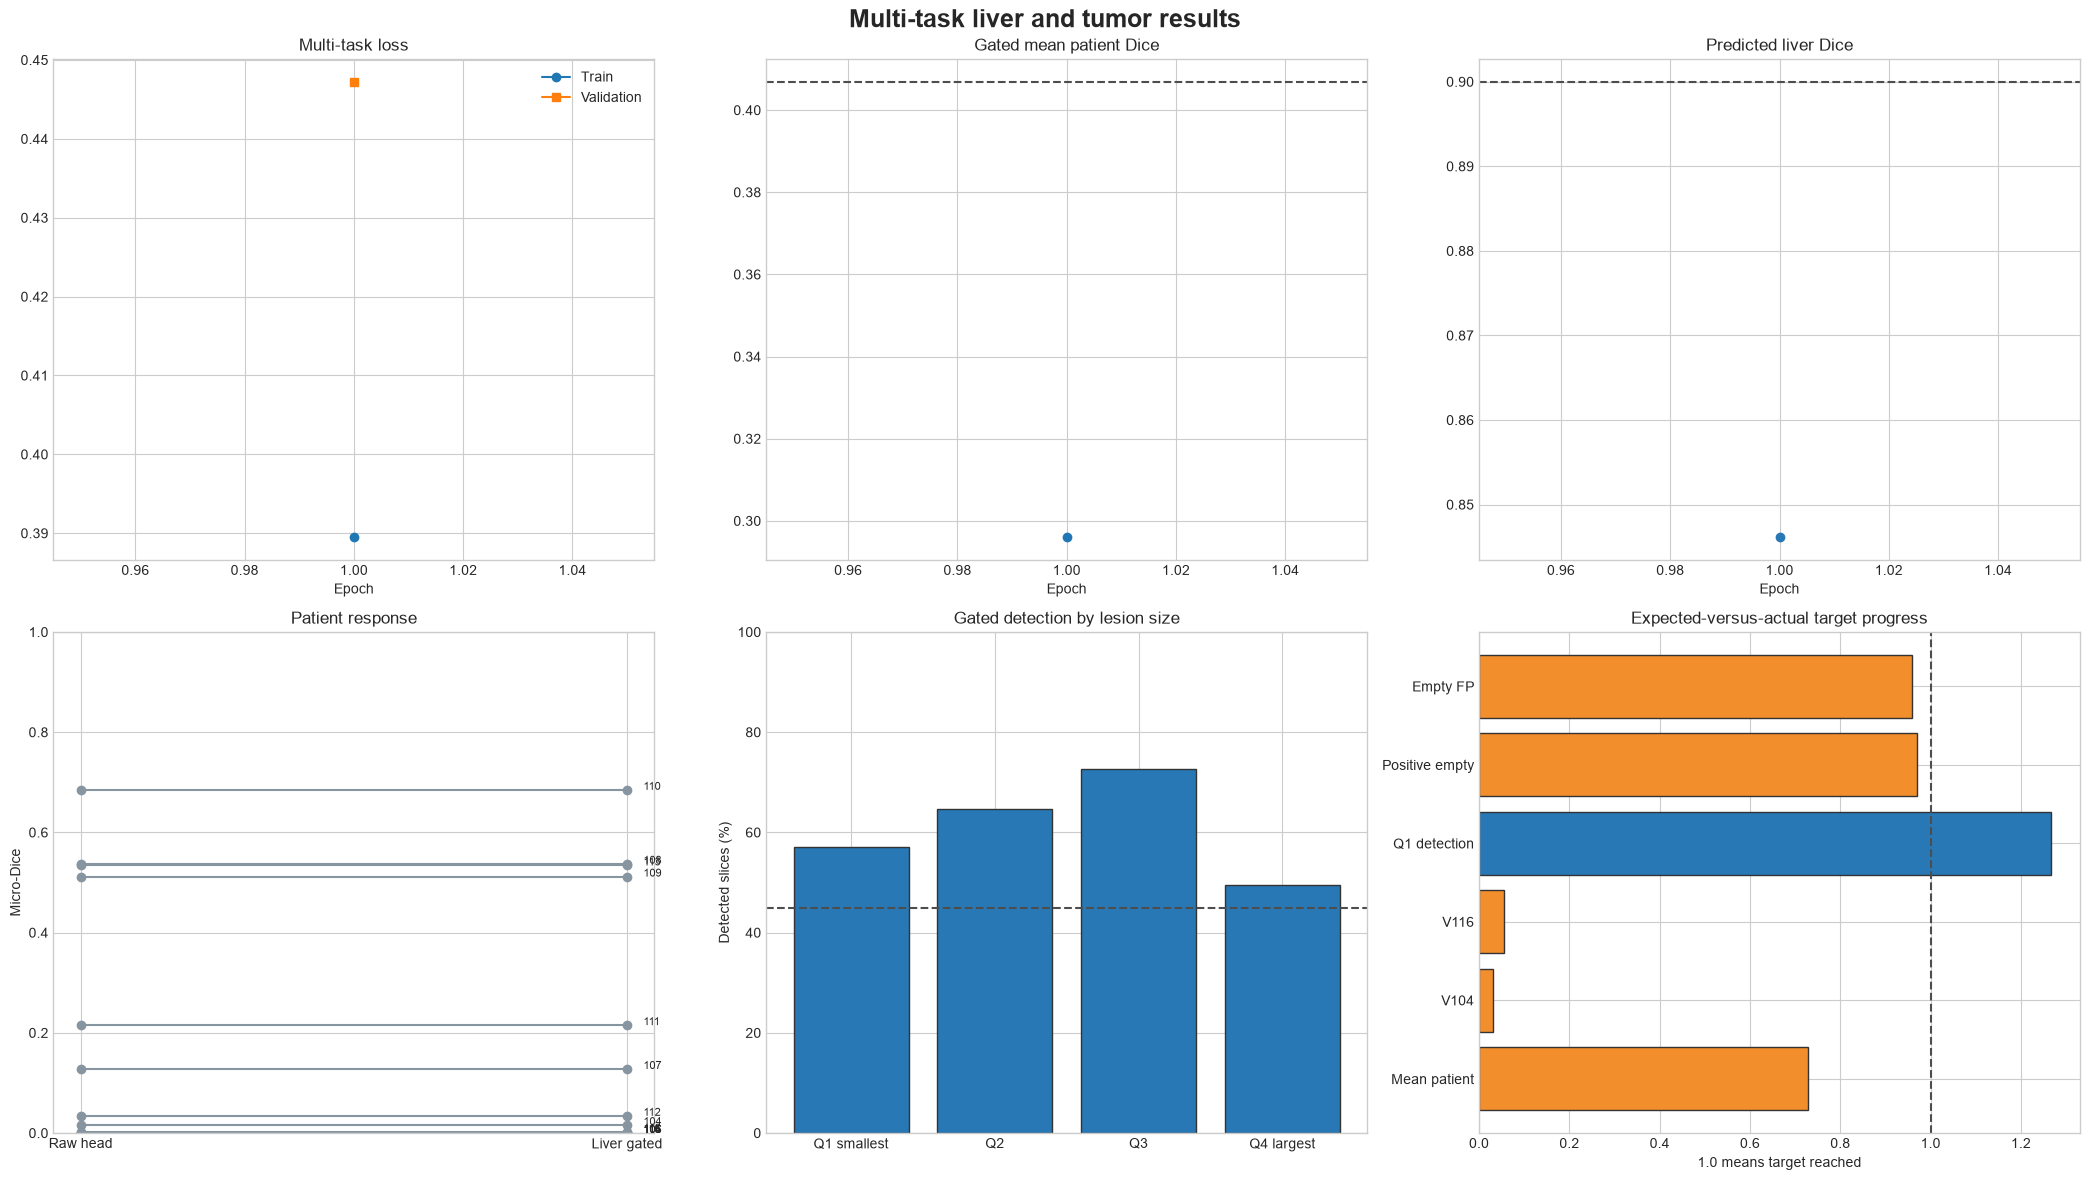

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes[0,0].plot(history_frame["epoch"], history_frame["train_total_loss"], marker="o", label="Train")
axes[0,0].plot(history_frame["epoch"], history_frame["val_loss"], marker="s", label="Validation")
axes[0,0].set_title("Multi-task loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()
axes[0,1].plot(history_frame["epoch"], history_frame["gated_mean_patient_dice"], marker="o")
axes[0,1].axhline(TARGETS["mean_patient_dice"], linestyle="--", color="#4D4D4D")
axes[0,1].set_title("Gated mean patient Dice"); axes[0,1].set_xlabel("Epoch")
axes[0,2].plot(history_frame["epoch"], history_frame["mean_liver_dice"], marker="o", color="#2878B5")
axes[0,2].axhline(TARGETS["mean_liver_dice"], linestyle="--", color="#4D4D4D")
axes[0,2].set_title("Predicted liver Dice"); axes[0,2].set_xlabel("Epoch")

pivot = patient_metrics.pivot(index="volume_id", columns="mode", values="micro_dice")
for volume_id, row in pivot.iterrows():
    axes[1,0].plot([0,1], [row["raw"],row["gated"]], marker="o", color="#8795A1")
    axes[1,0].text(1.03,row["gated"],str(volume_id),fontsize=8)
axes[1,0].set_xticks([0,1],["Raw head","Liver gated"])
axes[1,0].set_ylim(0,1); axes[1,0].set_title("Patient response"); axes[1,0].set_ylabel("Micro-Dice")

gated_sizes = size_metrics.loc[size_metrics["mode"].eq("gated")]
axes[1,1].bar(gated_sizes["size_quartile"].astype(str), gated_sizes["detected_pct"],
              color="#2878B5", edgecolor="#333333")
axes[1,1].axhline(TARGETS["q1_detected_pct"], linestyle="--", color="#4D4D4D")
axes[1,1].set_ylim(0,100); axes[1,1].set_title("Gated detection by lesion size")
axes[1,1].set_ylabel("Detected slices (%)")

metric_keys = ["mean_patient_dice","volume_104_dice","volume_116_dice",
               "q1_detected_pct","positive_predicted_empty_pct",
               "empty_slice_false_positive_pct"]
labels = ["Mean patient","V104","V116","Q1 detection","Positive empty","Empty FP"]
actual = [gated[k] for k in metric_keys]
target = [TARGETS[k] for k in metric_keys]
progress = [
    a/t if k not in ("positive_predicted_empty_pct","empty_slice_false_positive_pct")
    else t/max(a,1e-9)
    for k,a,t in zip(metric_keys,actual,target)
]
axes[1,2].barh(labels, progress,
               color=["#2878B5" if value>=1 else "#F28E2B" for value in progress],
               edgecolor="#333333")
axes[1,2].axvline(1,linestyle="--",color="#4D4D4D")
axes[1,2].set_title("Expected-versus-actual target progress")
axes[1,2].set_xlabel("1.0 means target reached")
fig.suptitle("Multi-task liver and tumor results",fontsize=18,weight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"multitask_results_dashboard.png",dpi=170,bbox_inches="tight")
plt.show()

### 10. Expected and generated mask inspection

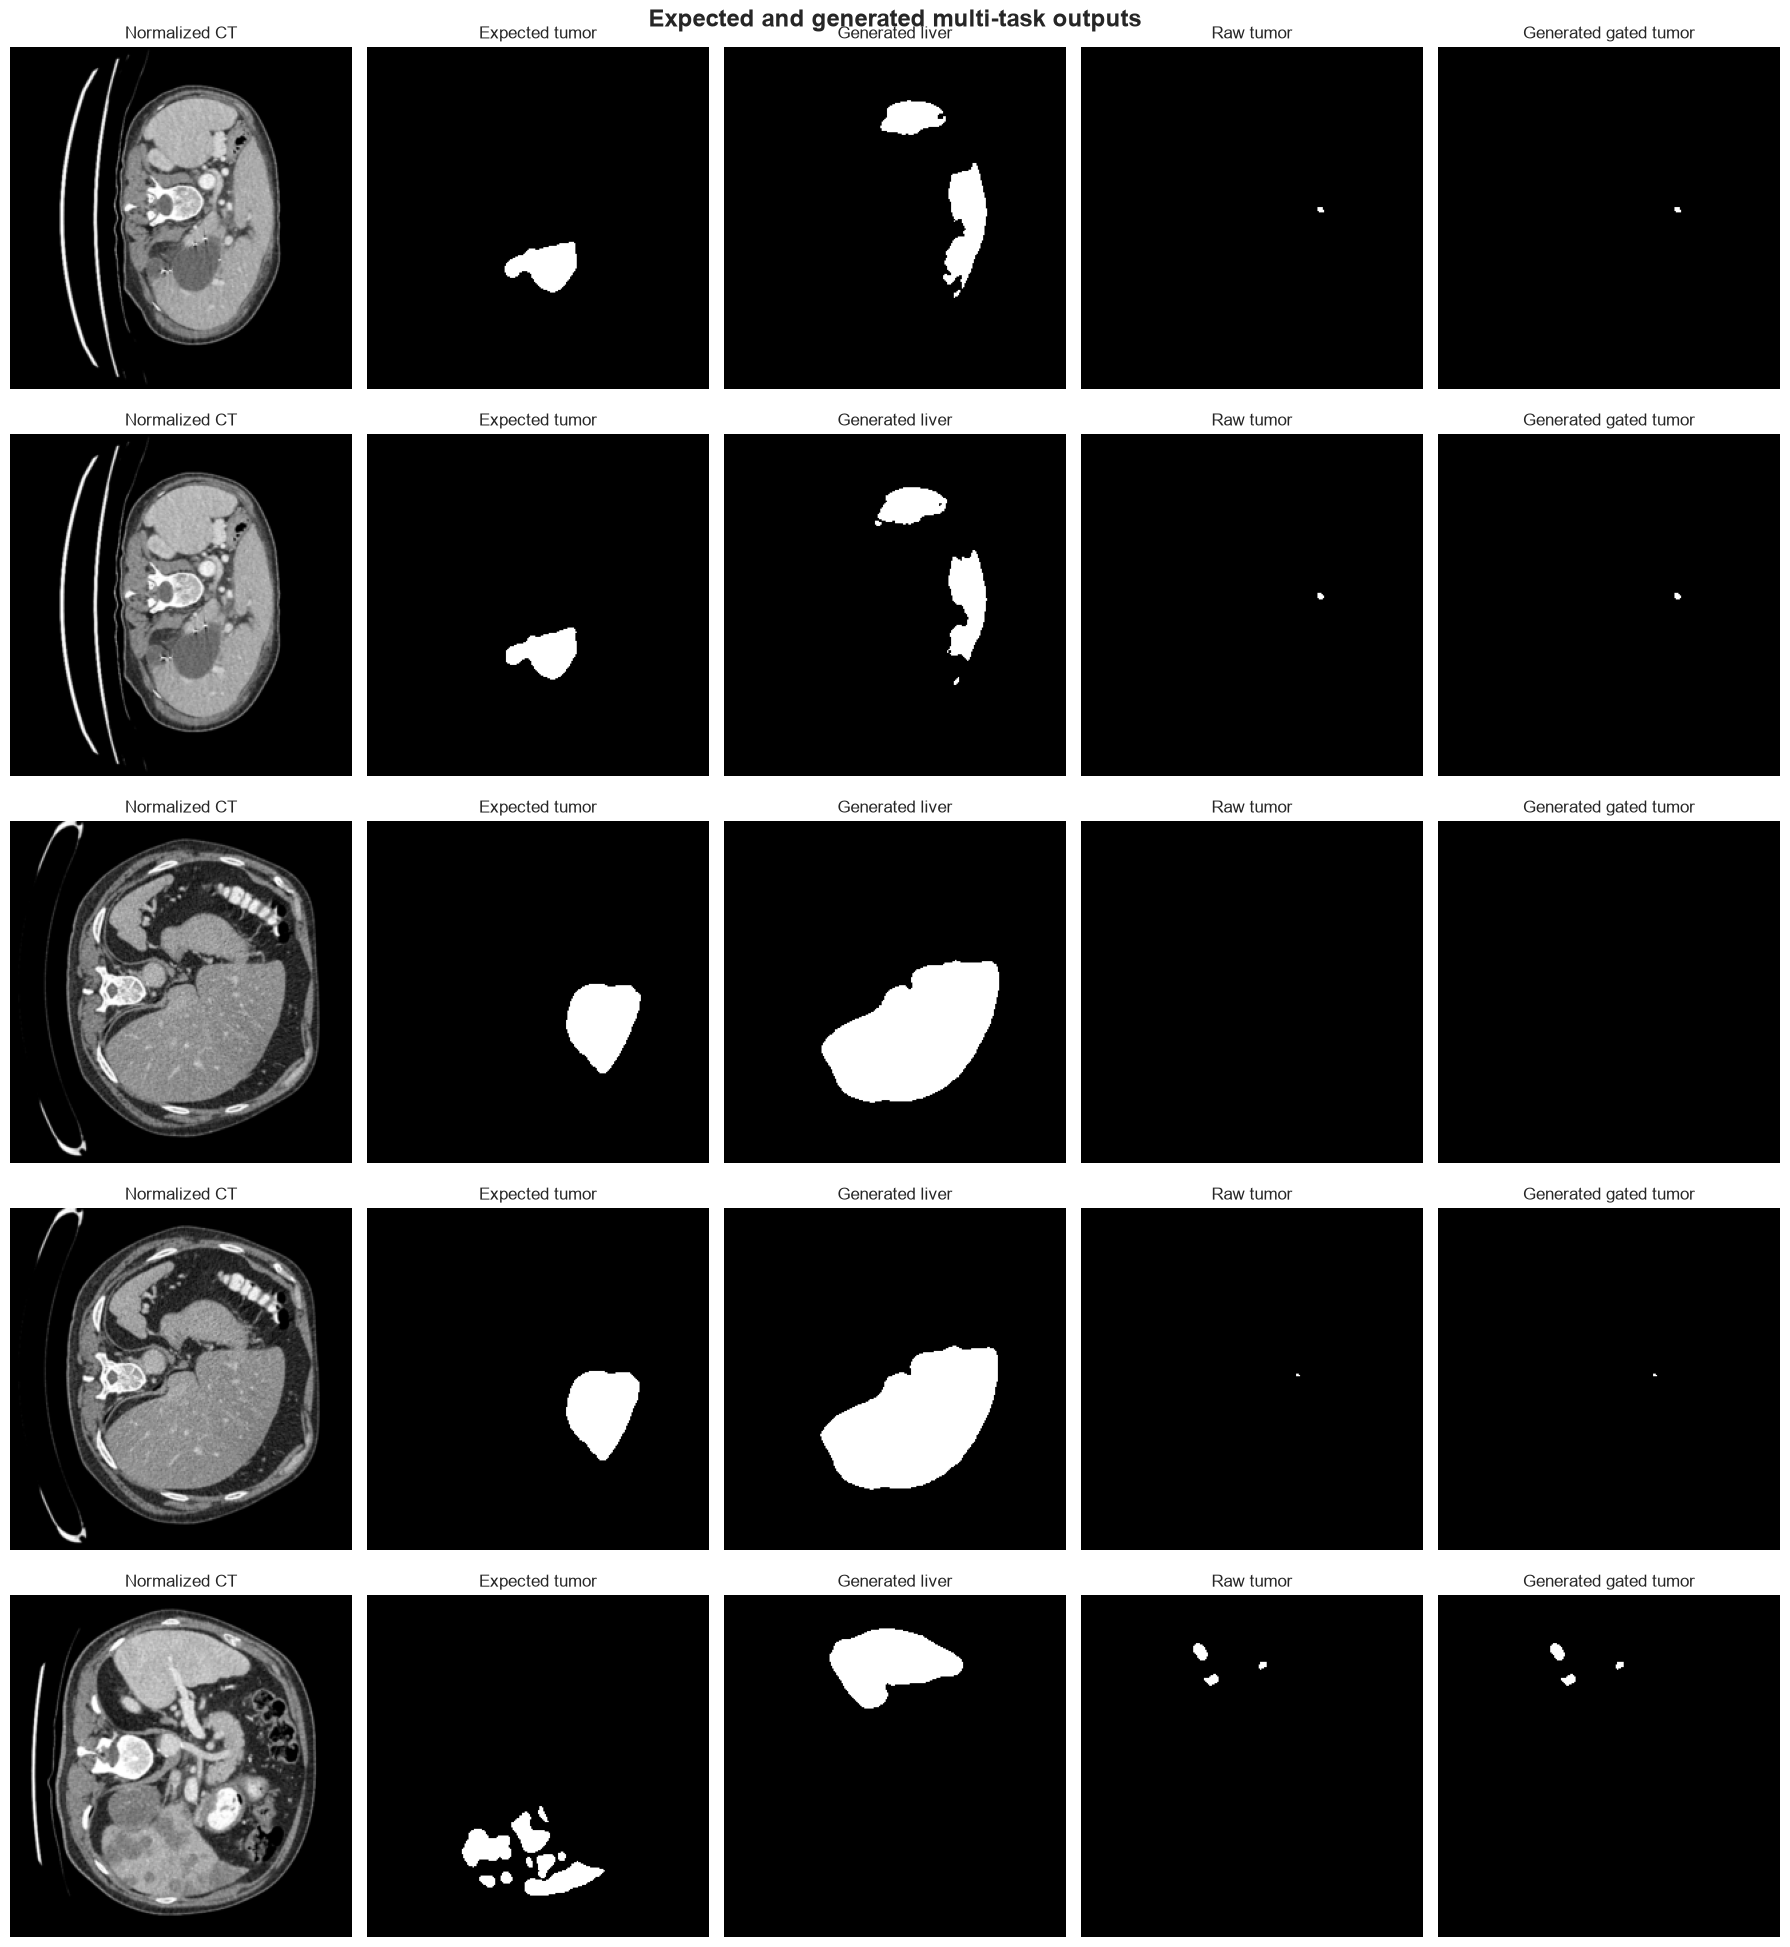

In [11]:
gated_rows = per_slice.loc[per_slice["mode"].eq("gated") & per_slice["true_pixels"].gt(0)].copy()
review_ids = []
for volume_id in (104,116):
    candidates = gated_rows.loc[gated_rows["volume_id"].eq(volume_id)]
    review_ids += candidates.nlargest(2,"true_pixels")["sample_id"].tolist()
review_ids += gated_rows.nsmallest(2,"dice")["sample_id"].tolist()
review_ids = list(dict.fromkeys(review_ids))[:6]
indices = [val_base.sample_ids.index(sample_id) for sample_id in review_ids]
review_loader = DataLoader(torch.utils.data.Subset(val_dataset, indices),
                           batch_size=len(indices), shuffle=False)
batch = next(iter(review_loader))
with torch.inference_mode():
    logits = model(batch["image"].to(device))
    raw, gated_prediction_batch = gated_prediction(logits)
    liver_prediction = torch.sigmoid(logits[:,0:1]) >= LIVER_THRESHOLD
fig, axes = plt.subplots(len(indices),5,figsize=(18,4*len(indices)))
if len(indices)==1: axes=axes[None,:]
for i,row_axes in enumerate(axes):
    panels = [
        (batch["image"][i,0], "Normalized CT", "gray"),
        (batch["mask"][i,0], "Expected tumor", "gray"),
        (liver_prediction[i,0].cpu(), "Generated liver", "gray"),
        (raw[i,0].cpu(), "Raw tumor", "gray"),
        (gated_prediction_batch[i,0].cpu(), "Generated gated tumor", "gray"),
    ]
    for axis,(panel,title,cmap) in zip(row_axes,panels):
        axis.imshow(panel,cmap=cmap); axis.set_title(title); axis.axis("off")
    row_axes[0].set_ylabel(str(batch["sample_id"][i]),fontsize=8)
fig.suptitle("Expected and generated multi-task outputs",fontsize=17,weight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"expected_vs_generated_predictions.png",dpi=170,bbox_inches="tight")
plt.show()

## Takeaways

### 11. Final validation gate

In [12]:
metrics = {
    **gated,
    "mean_liver_dice": float(result["mean_liver_dice"]),
}
passes = {
    key: metrics[key] >= value
    for key,value in TARGETS.items()
    if key not in ("positive_predicted_empty_pct","empty_slice_false_positive_pct")
}
passes.update({
    key: metrics[key] <= TARGETS[key]
    for key in ("positive_predicted_empty_pct","empty_slice_false_positive_pct")
})
gate_passed = all(passes.values())
gate = {
    "status": "multitask_localization_pass" if gate_passed else "multitask_localization_fail",
    "manifest_sha256": manifest_hash,
    "source_checkpoint_sha256": source_checkpoint_hash,
    "best_epoch": best_epoch,
    **{key: float(metrics[key]) for key in TARGETS},
    "targets_passed": int(sum(passes.values())),
    "all_expected_targets_passed": gate_passed,
    "ground_truth_organ_used_for_validation_preprocessing": False,
    "ground_truth_organ_used_for_validation_gating": False,
    "test_images_accessed": False,
    "decision": (
        "PASS — freeze this model and gating rule before one locked-test evaluation."
        if gate_passed else
        "FAIL — keep test locked and inspect whether errors are inside predicted liver or caused by missed liver support."
    ),
}
(OUTPUT_DIR/"multitask_localization_gate_result.json").write_text(json.dumps(gate,indent=2))
expected_actual = pd.DataFrame([
    {"metric":key,"target":TARGETS[key],"actual":metrics[key],"passed":passes[key]}
    for key in TARGETS
])
expected_actual.to_csv(OUTPUT_DIR/"expected_vs_actual_results.csv",index=False)
display(pd.DataFrame([gate]).T.rename(columns={0:"value"}))
display(expected_actual)
print(gate["decision"])

,value
status,multitask_localization_fail
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
source_checkpoint_sha256,5f18223c0f618d45d1433dc4a48d950fdea8a039db9ea5...
best_epoch,1
mean_patient_dice,0.296019
volume_104_dice,0.015861
volume_116_dice,0.002742
q1_detected_pct,57.034221
positive_predicted_empty_pct,20.633397
empty_slice_false_positive_pct,15.638287


,metric,target,actual,passed
0,mean_patient_dice,0.406915,0.296019,False
1,volume_104_dice,0.500000,0.015861,False
2,volume_116_dice,0.050000,0.002742,False
3,q1_detected_pct,45.000000,57.034221,True
4,positive_predicted_empty_pct,20.000000,20.633397,False
5,empty_slice_false_positive_pct,15.000000,15.638287,False
6,mean_liver_dice,0.900000,0.846144,False


FAIL — keep test locked and inspect whether errors are inside predicted liver or caused by missed liver support.


### Interpretation guide

- If the liver head passes but tumor false positives remain high, false positives are anatomically plausible and the next change should target tumor discrimination or hard negatives.
- If liver Dice or volume 116 liver support fails, inspect normalization and organ-domain shift before changing tumor loss.
- If all targets pass, freeze the complete configuration before requesting a single test evaluation.
- Ground-truth liver masks must never replace predicted liver support during reported validation or test inference.